# Autoencoders using Fashion-MNIST

## Objective

The objective of this project is to implement Autoencoders using the Fashion-MNIST dataset.

We focus on:
- Denoising Autoencoder
- Sparse Autoencoder

## Goals:
- Learn compressed representations of images
- Remove noise from corrupted images
- Reconstruct original images
- Analyze data patterns

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

C:\Users\Cpu\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Dataset Loading

Fashion-MNIST is a dataset of grayscale images of clothing items.
Each image is 28x28 pixels.

In [2]:
# Load dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()

print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step 
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train Shape: (60000, 28, 28)
Test Shape: (10000, 28, 28)


## Basic Data Analysis

We check:
- Shape
- Data type
- Min and max values

In [3]:
print("Data type:", x_train.dtype)

Data type: uint8


In [4]:
print("Min value:", x_train.min())

Min value: 0


In [5]:
print("Max value:", x_train.max())

Max value: 255


## Visualization of Images

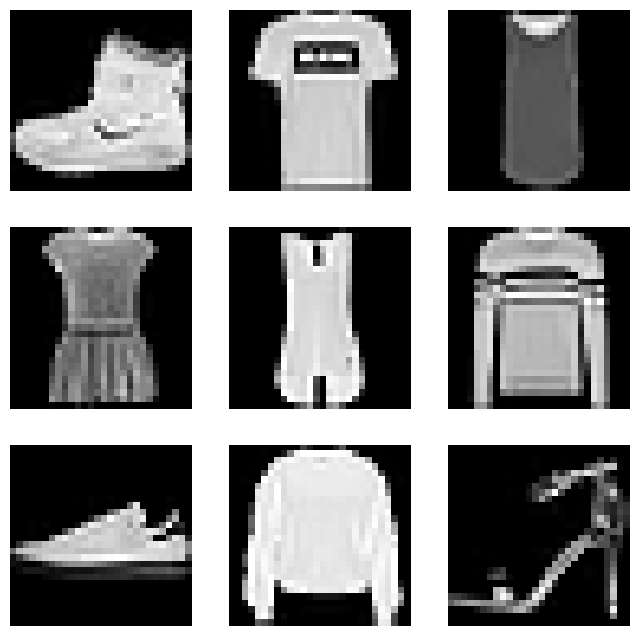

In [6]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
plt.show()

## Data Preprocessing

Steps:
- Normalize pixel values
- Flatten images into 784 dimension vectors

In [7]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print("Flattened shape:", x_train.shape)

Flattened shape: (60000, 784)


## Checking for Duplicates and Missing Values

In [8]:
# Convert to DataFrame for analysis
df = pd.DataFrame(x_train)

# Check duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

# Check missing values
print("Missing values:", df.isnull().sum().sum())

Duplicate rows: 0
Missing values: 0


## Adding Noise (Denoising Autoencoder)

We add Gaussian noise to simulate corrupted images.

In [10]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

## Visualizing Noisy Images

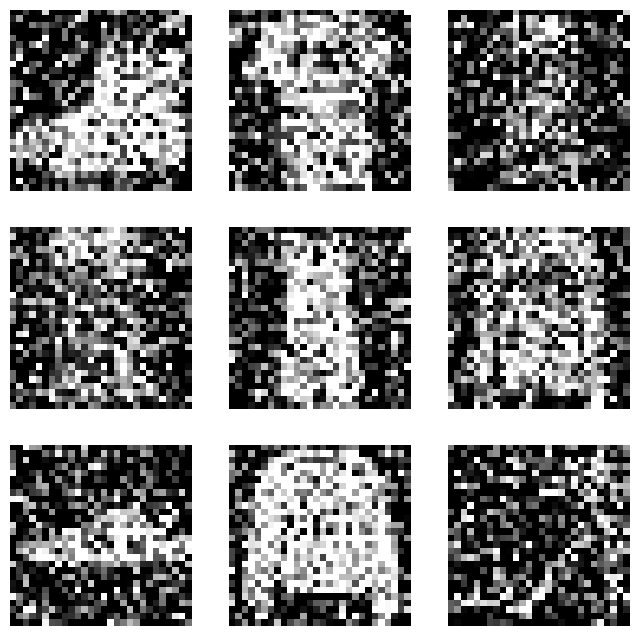

In [11]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()

## Building Denoising Autoencoder

In [12]:
input_dim = 784
encoding_dim = 128

input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(256, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(256, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Model
autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

## Training Model

In [13]:
autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.3728 - val_loss: 0.3258
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3162 - val_loss: 0.3135
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3078 - val_loss: 0.3083
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3032 - val_loss: 0.3045
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2999 - val_loss: 0.3018
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.2974 - val_loss: 0.3003
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2955 - val_loss: 0.2983
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2941 - val_loss: 0.2971
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2928 - val_loss: 0.2965
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2918 - val_loss: 0.2958
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2909 - val_loss: 0.2956
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

## Reconstruction Results

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


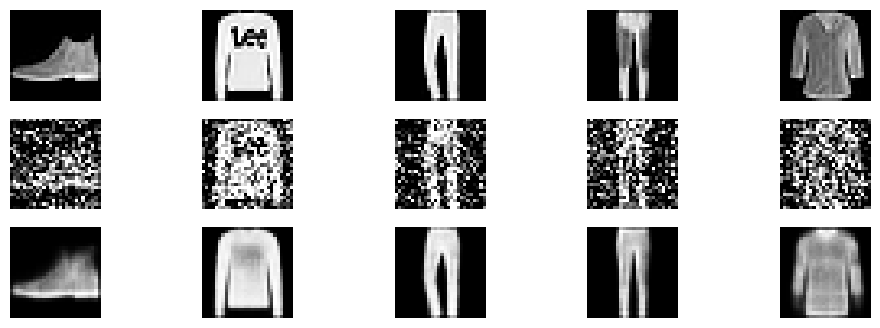

In [14]:
decoded_imgs = autoencoder.predict(x_test_noisy)

plt.figure(figsize=(12,4))

# Original
for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

# Noisy
for i in range(5):
    plt.subplot(3,5,i+6)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

# Reconstructed
for i in range(5):
    plt.subplot(3,5,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

## Sparse Autoencoder

Sparse Autoencoder encourages fewer neurons to activate.

In [16]:
from tensorflow.keras import regularizers

input_layer = Input(shape=(784,))
encoded = Dense(128, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_layer)
decoded = Dense(784, activation='sigmoid')(encoded)

sparse_autoencoder = Model(input_layer, decoded)
sparse_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [17]:
sparse_autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5753 - val_loss: 0.4626
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4331 - val_loss: 0.4107
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3897 - val_loss: 0.3782
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3685 - val_loss: 0.3636
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3570 - val_loss: 0.3547
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3503 - val_loss: 0.3497
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3463 - val_loss: 0.3465
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3436 - val_loss: 0.3444
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3417 - val_loss: 0.3427
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3401 - val_loss: 0.3412
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3388 - val_loss: 0.3400
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

## Conclusion

The denoising autoencoder successfully removed noise and reconstructed images.

The sparse autoencoder learned efficient compressed representations.

This project demonstrates how autoencoders can be used for:
- Noise removal
- Feature learning
- Dimensionality reduction